In [10]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from scipy import stats
import math
import ee
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


PRECIPITAÇÃO

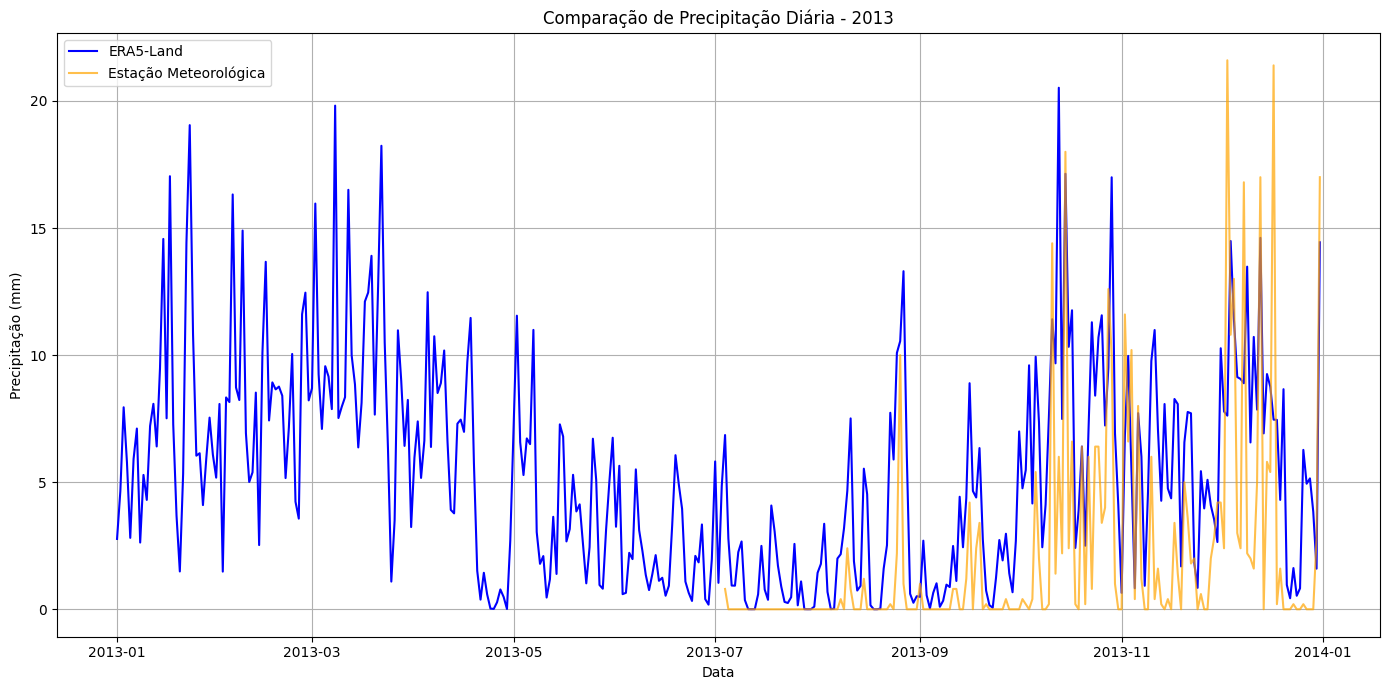

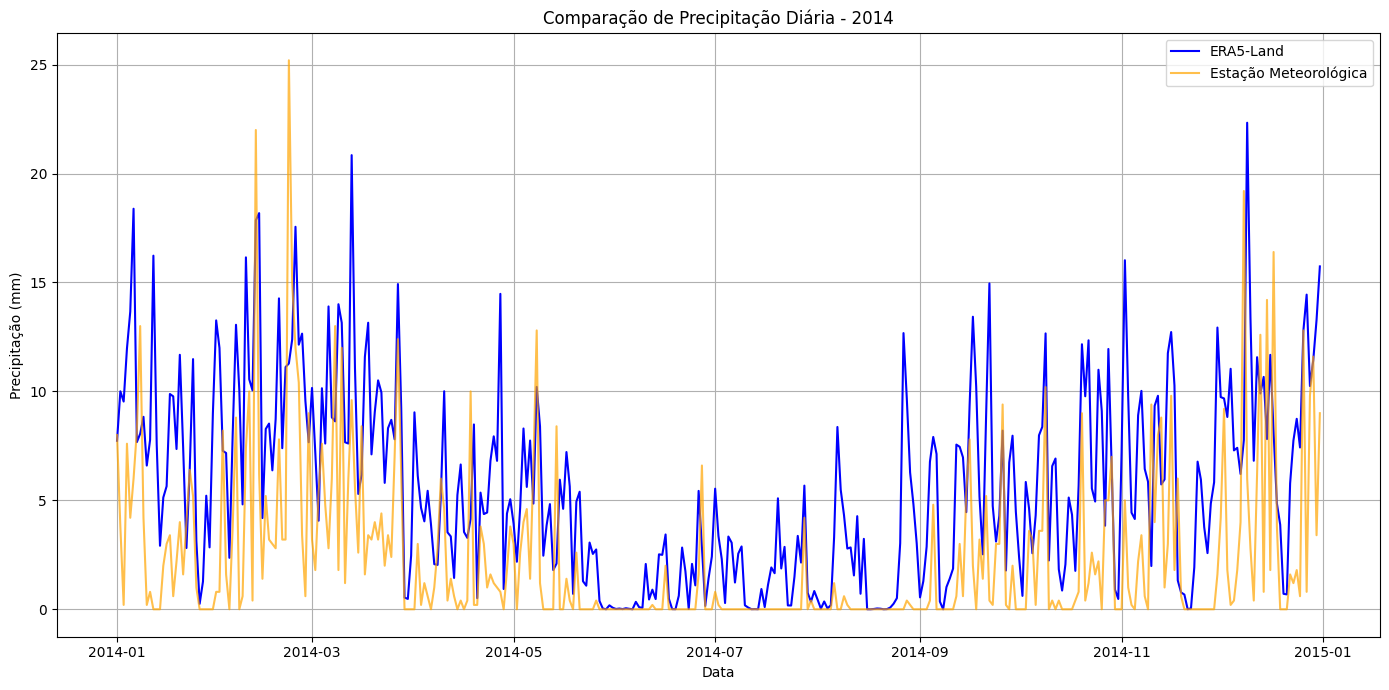

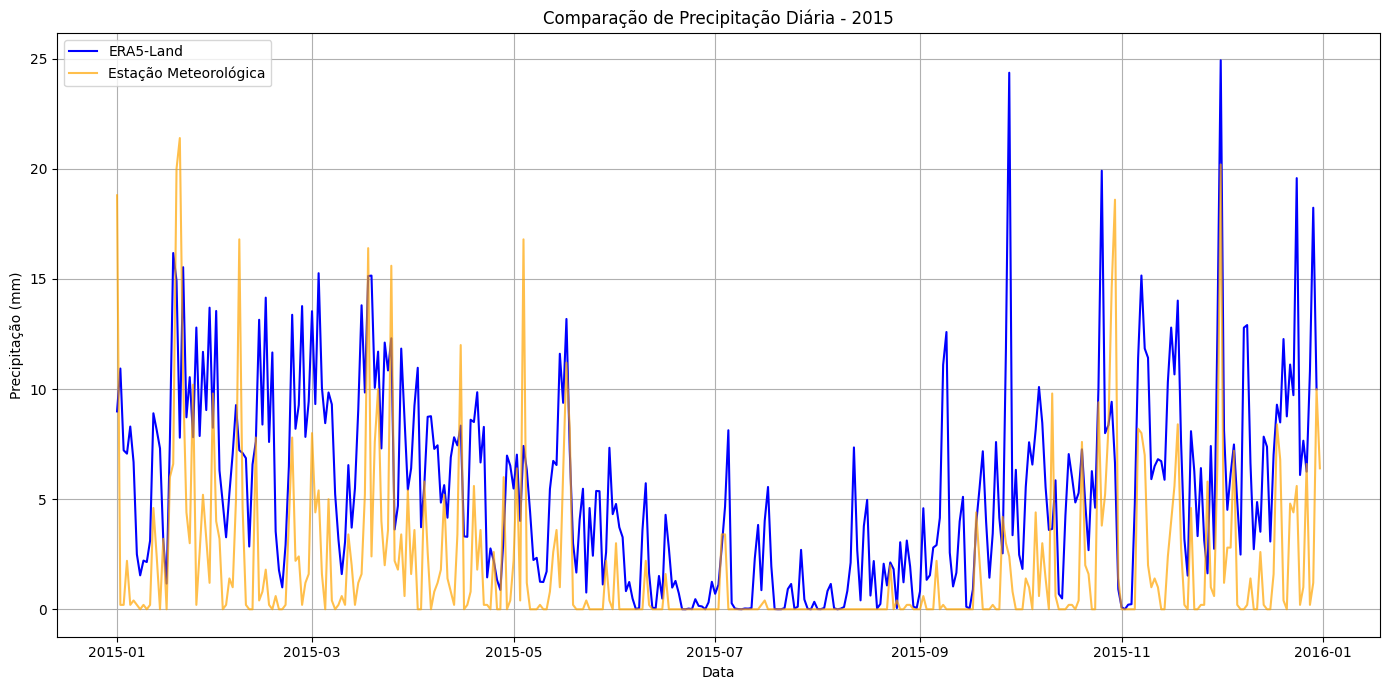

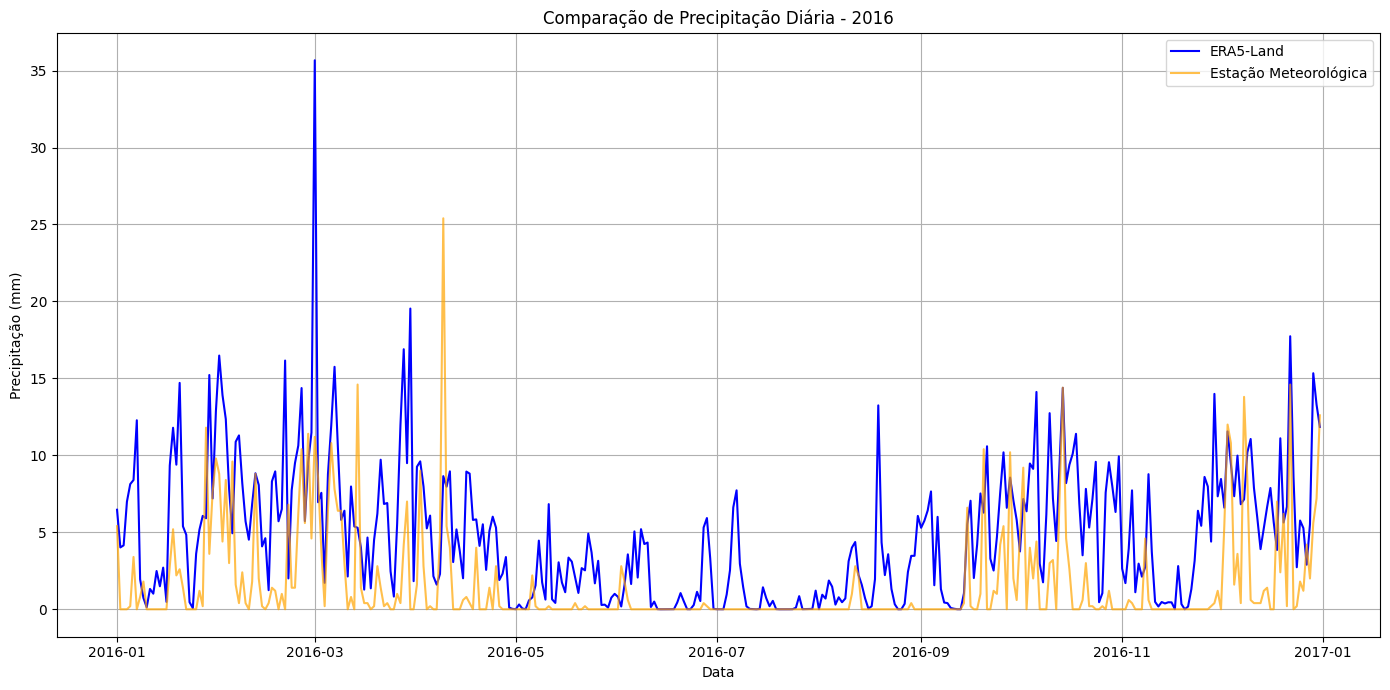

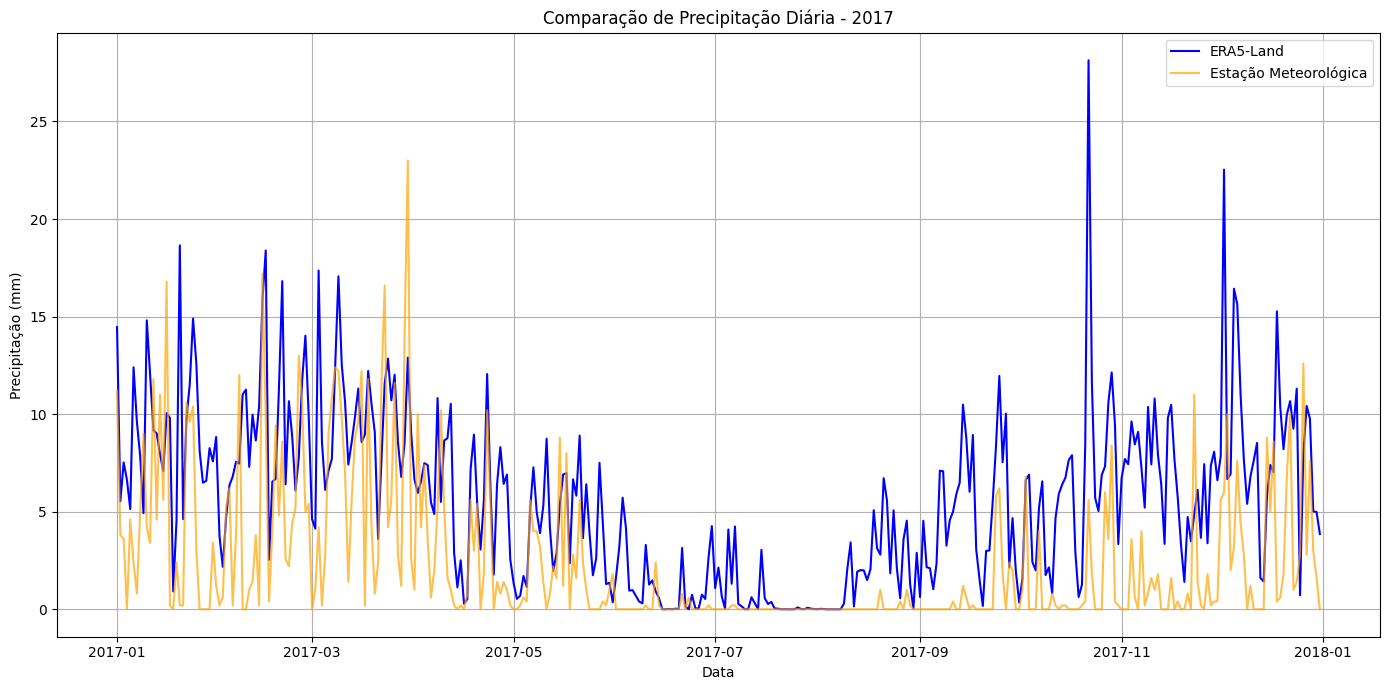

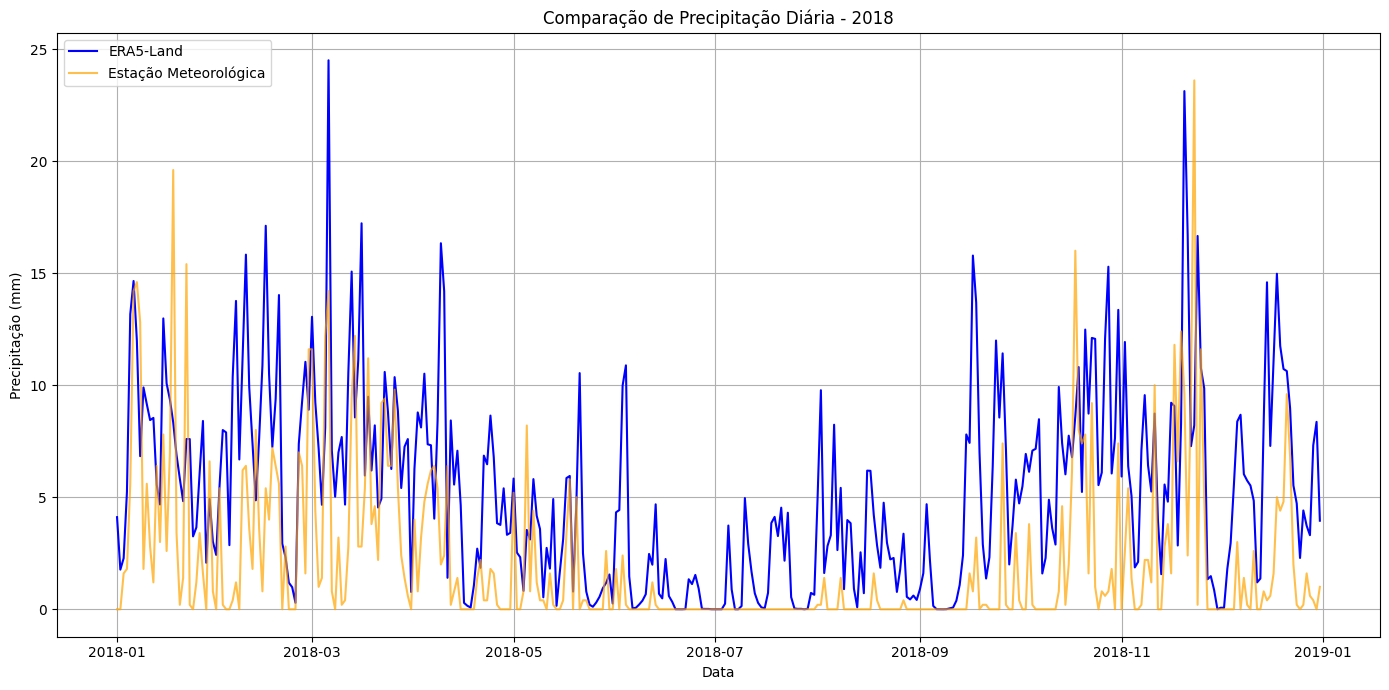

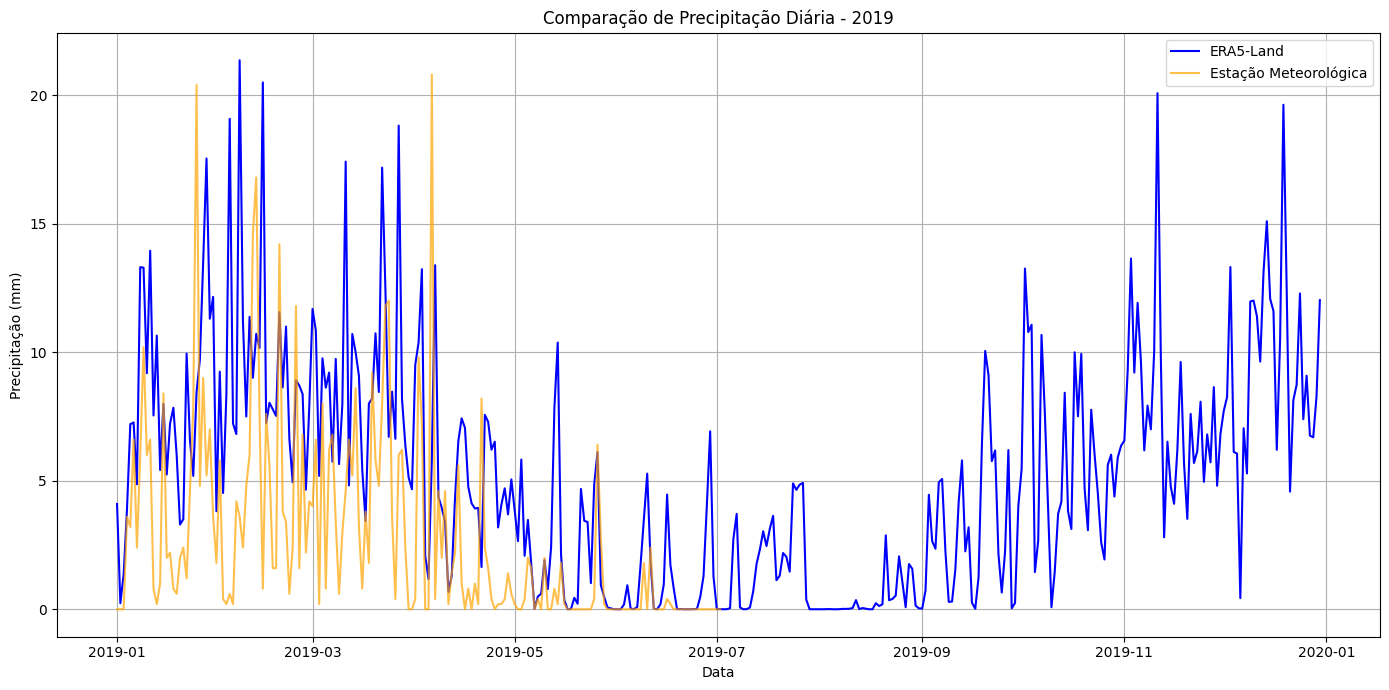

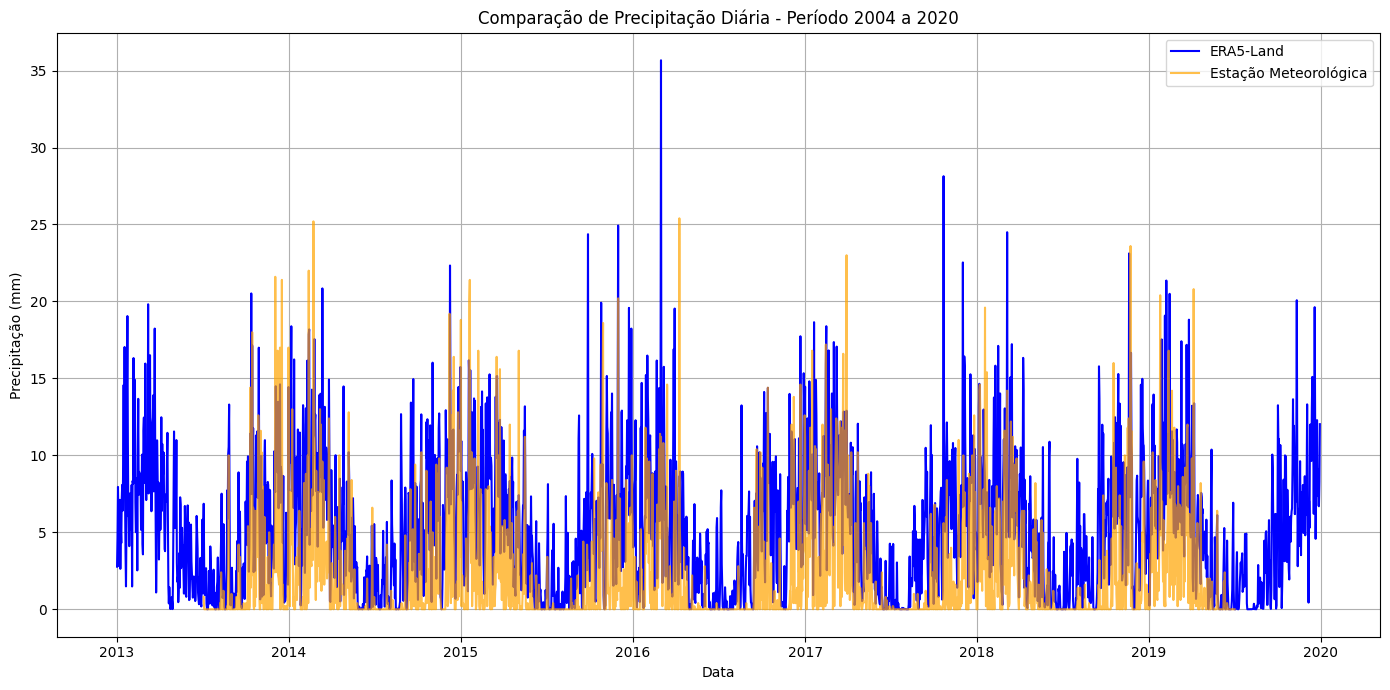

In [17]:

# -----------------------------
# Inicializar a API do Google Earth Engine
# -----------------------------
ee.Initialize()

# -----------------------------
# Dados ERA5‑Land (Google Earth Engine)
# -----------------------------
# Definir os dados da estação (coordenadas, nome e cor)
station = {"name": "CDAWX", "lat": -9.46 , "lon": -77.37, "color": "green"}

# Carregar a coleção de imagens diária do ERA5‑Land e selecionar a variável de precipitação
era5_land_daily = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR").select("total_precipitation_sum")

# Função para extrair a precipitação diária de um ponto em um intervalo de datas
def get_daily_precipitation(image_collection, point, start_date, end_date):
    period_collection = image_collection.filterDate(start_date, end_date)
    
    def extract_data(image):
        date = ee.Date(image.get("system:time_start"))
        value = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=9000,
            maxPixels=1e9
        ).get("total_precipitation_sum")
        return ee.Feature(None, {
            "date": date.format("YYYY-MM-dd"),
            "value": ee.Number(value).multiply(1000)  # Converter de m para mm
        })
    
    features = period_collection.map(extract_data).getInfo()["features"]
    data = [
        {
            "date": pd.to_datetime(feature["properties"]["date"]),
            "value": feature["properties"]["value"]
        }
        for feature in features if feature["properties"]["value"] is not None
    ]
    return pd.DataFrame(data)

# Dividir o período em intervalos para evitar limites de requisição (2004 a 2020)
date_ranges = [
    ("2013-01-01", "2013-12-31"),
    ("2013-01-01", "2015-12-31"),
    ("2016-01-01", "2019-12-31")
]

# Obter os dados do ERA5‑Land para o ponto da estação
point = ee.Geometry.Point([station["lon"], station["lat"]])
dfs = []
for start_date, end_date in date_ranges:
    df = get_daily_precipitation(era5_land_daily, point, start_date, end_date)
    dfs.append(df)
era5_df = pd.concat(dfs)
era5_df.sort_values(by='date', inplace=True)

# -----------------------------
# Dados da Estação Meteorológica
# -----------------------------
# Caminho para o arquivo CSV (ajuste conforme necessário)

f = '../../Weather Station Data/CasaDeAgua_CDAWX_4July13_1July19.csv'
dados = pd.read_csv(f, encoding="latin1")


# Converter a coluna de data para datetime
dados['Data'] = pd.to_datetime(dados['Datetime'], format='%m/%d/%Y %H:%M')

# Filtrar o período de interesse: 2004-01-01 a 2020-12-31
mask = (dados['Data'] >= '2004-01-01') & (dados['Data'] <= '2020-12-31')
dados = dados[mask]

# Calcular a soma diária da precipitação
dados.set_index('Data', inplace=True)
soma_diaria = dados['Precipitation (mm)'].resample('D').sum().reset_index()
station_df = soma_diaria.rename(columns={'Data': 'date', 'Precipitation (mm)': 'value'})
station_df.sort_values(by='date', inplace=True)

# -----------------------------
# Gráficos Comparativos por Ano (2004 a 2020)
# -----------------------------
anos = range(2004, 2021)  # De 2004 até 2020

for ano in anos:
    # Filtrar os dados para o ano atual
    era5_ano = era5_df[era5_df['date'].dt.year == ano]
    station_ano = station_df[station_df['date'].dt.year == ano]
    
    # Caso algum dos conjuntos não possua dados para o ano, pula o gráfico
    if era5_ano.empty or station_ano.empty:
        continue

    plt.figure(figsize=(14, 7))
    plt.plot(era5_ano["date"], era5_ano["value"], label="ERA5‑Land", color="blue")
    plt.plot(station_ano["date"], station_ano["value"], label="Estação Meteorológica", color="orange", alpha=0.7)
    plt.title(f"Comparação de Precipitação Diária - {ano}")
    plt.xlabel("Data")
    plt.ylabel("Precipitação (mm)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Gráfico Comparativo para Todo o Período (2004 a 2020)
# -----------------------------
plt.figure(figsize=(14, 7))
plt.plot(era5_df["date"], era5_df["value"], label="ERA5‑Land", color="blue")
plt.plot(station_df["date"], station_df["value"], label="Estação Meteorológica", color="orange", alpha=0.7)
plt.title("Comparação de Precipitação Diária - Período 2004 a 2020")
plt.xlabel("Data")
plt.ylabel("Precipitação (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Text(0.05, 0.95, '$r=0.54$\n$Bias=-3.17$\n$RMSE=5.08$')

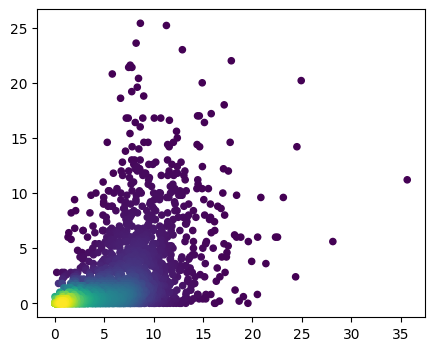

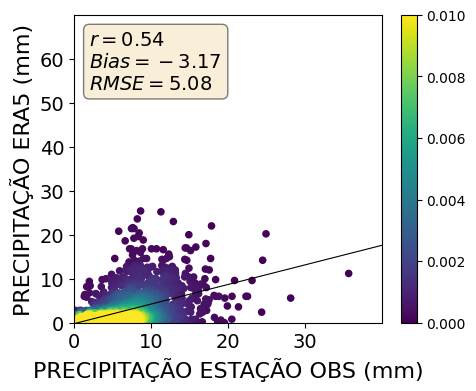

In [18]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from scipy import stats
import math
import ee
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# -----------------------------
# Inicializar a API do Google Earth Engine
# -----------------------------
ee.Initialize()

# -----------------------------
# Dados ERA5‑Land (Google Earth Engine)
# -----------------------------
# Definir os dados da estação (coordenadas, nome e cor)
station = {"name": "CDAWX", "lat": -9.46 , "lon": -77.37, "color": "green"}

# Carregar a coleção de imagens diária do ERA5‑Land e selecionar a variável de precipitação
era5_land_daily = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR").select("total_precipitation_sum")

# Função para extrair a precipitação diária de um ponto em um intervalo de datas
def get_daily_precipitation(image_collection, point, start_date, end_date):
    period_collection = image_collection.filterDate(start_date, end_date)
    
    def extract_data(image):
        date = ee.Date(image.get("system:time_start"))
        value = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=9000,
            maxPixels=1e9
        ).get("total_precipitation_sum")
        return ee.Feature(None, {
            "date": date.format("YYYY-MM-dd"),
            "value": ee.Number(value).multiply(1000)  # Converter de m para mm
        })
    
    features = period_collection.map(extract_data).getInfo()["features"]
    data = [
        {
            "date": pd.to_datetime(feature["properties"]["date"]),
            "value": feature["properties"]["value"]
        }
        for feature in features if feature["properties"]["value"] is not None
    ]
    return pd.DataFrame(data)

# Dividir o período em intervalos para evitar limites de requisição (2004 a 2020)
date_ranges = [
    ("2004-01-01", "2006-12-31"),
    ("2007-01-01", "2009-12-31"),
    ("2010-01-01", "2012-12-31"),
    ("2013-01-01", "2015-12-31"),
    ("2016-01-01", "2020-12-31")
]

# Obter os dados do ERA5‑Land para o ponto da estação
point = ee.Geometry.Point([station["lon"], station["lat"]])
dfs = []
for start_date, end_date in date_ranges:
    df = get_daily_precipitation(era5_land_daily, point, start_date, end_date)
    dfs.append(df)
era5_df = pd.concat(dfs)
era5_df.sort_values(by='date', inplace=True)


f = '../../Weather Station Data/CasaDeAgua_CDAWX_4July13_1July19.csv'
dados = pd.read_csv(f, encoding="latin1")
# Converter a coluna de data para datetime
dados['Data'] = pd.to_datetime(dados['Datetime'], format='%m/%d/%Y %H:%M')

# Calcular a soma diária da precipitação
dados.set_index('Data', inplace=True)
soma_diaria = dados['Precipitation (mm)'].resample('D').sum().reset_index()
station_df = soma_diaria.rename(columns={'Data': 'date', 'Precipitation (mm)': 'value'})
station_df.sort_values(by='date', inplace=True)


era5_df = era5_df.set_index('date')
station_df = station_df.set_index('date')


T2_all = pd.merge(era5_df, station_df, how='left', left_index=True, right_index=True)
T2_all.columns = ['ERA5', 'CDAWX']

# 1. Remover linhas que não possuem dados (NaN) em ambas as medições
T2_all = T2_all.dropna(subset=['ERA5', 'CDAWX'])
#T2_all = T2_all[(T2_all['ERA5'] != 0) & (T2_all['CDAWX'] != 0)]

df_corr = T2_all

y1 = df_corr['ERA5'].values
y2 = df_corr['CDAWX'].values
idxs = np.arange(len(y1))
np.random.shuffle(idxs)
n_toplot=10**10
y_expected = y1.reshape(-1)[idxs[:n_toplot]]
y_predicted = y2.reshape(-1)[idxs[:n_toplot]]
xy = np.vstack([y_expected, y_predicted])
z = gaussian_kde(xy)(xy)
idx = z.argsort()
y_plt, ann_plt, z = y_expected[idx], y_predicted[idx], z[idx]

fig = plt.figure(figsize=(5,4))
sc = plt.scatter(y_plt, ann_plt, c=z, s=20)



reg = LinearRegression().fit(y1.reshape(-1, 1),y2)
x_int = np.arange(0,60,0.5)

def sts_ind_SMB_dec(ds1):
    ds1 = ds1.dropna()
    ds1.columns = ['OBS', 'SIM']
    r  = stats.pearsonr(ds1['OBS'], ds1['SIM'])[0]
    MBE = np.mean(ds1['SIM'] - ds1['OBS']) 
    MSE  = np.square(np.subtract(ds1['OBS'], ds1['SIM'])).mean() 
    RMSE = math.sqrt(MSE)

    textstr = '\n'.join((
    r'$r=%.2f$' % (r, ),
    r'$Bias=%.2f$' % (MBE, ),
    r'$RMSE=%.2f$' % (RMSE, )))

    return textstr


fig = plt.figure(figsize=(5,4))
sc = plt.scatter(y_plt, ann_plt, c=z, s=20)

plt.colorbar(sc)
plt.clim(0,0.01)
plt.tick_params(labelsize=14)

plt.ylabel('PRECIPITAÇÃO ERA5 (mm)', fontsize=16)
plt.xlabel('PRECIPITAÇÃO ESTAÇÃO OBS (mm)', fontsize=16)

plt.gca().set_box_aspect(1)
plt.xticks(np.arange(0,40,10))
plt.yticks(np.arange(0,70,10))

plt.xlim(0, 40)
plt.ylim(0, 70)

# Adicionamos regressão linea
plt.plot(x_int, reg.intercept_ + reg.coef_ * x_int, linewidth=0.8, color='k', linestyle ='-')

# Vamos adicionar uma caixa para mostrar os indicadores estatísticos. Aqui configuramos as propriedades da caixa
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

# Agora podemos adicionar nossos indicadores estatísticos
plt.text(0.05, 0.95, sts_ind_SMB_dec(df_corr), transform=plt.gca().transAxes, fontsize=14,
        verticalalignment='top', bbox=props)


TEMPERATURA

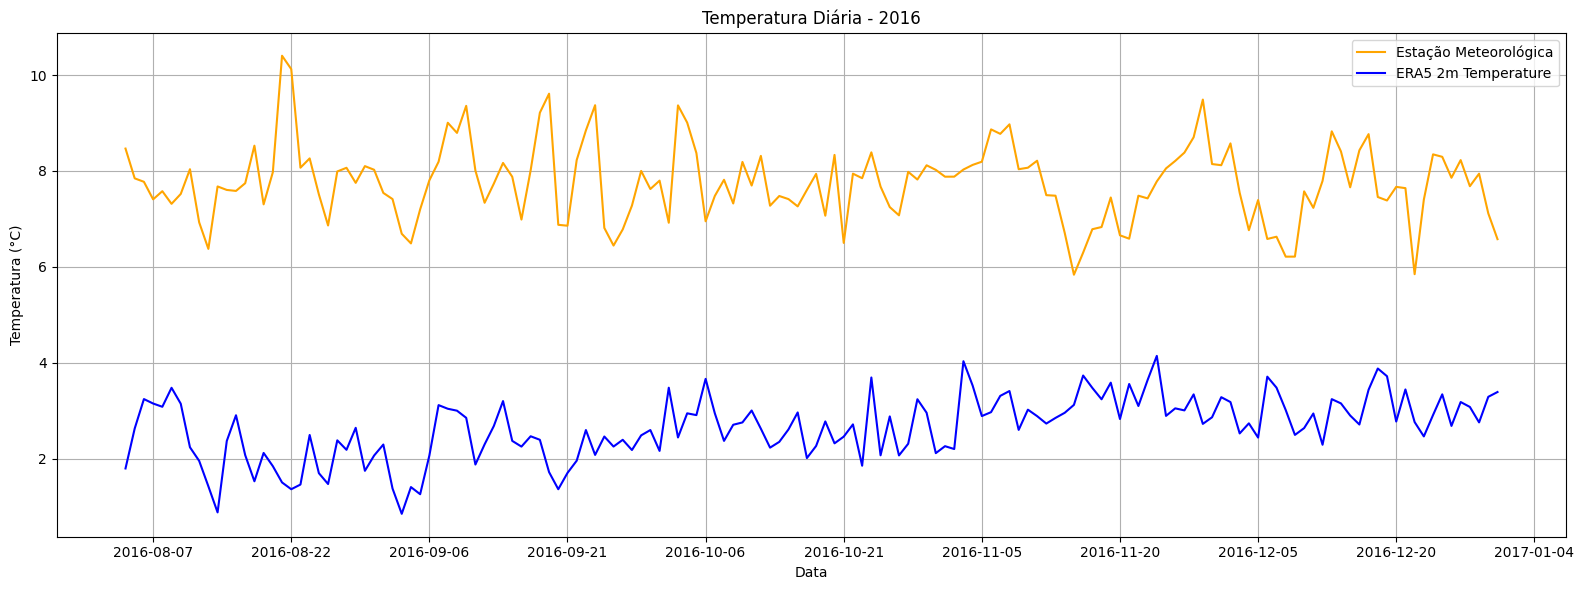

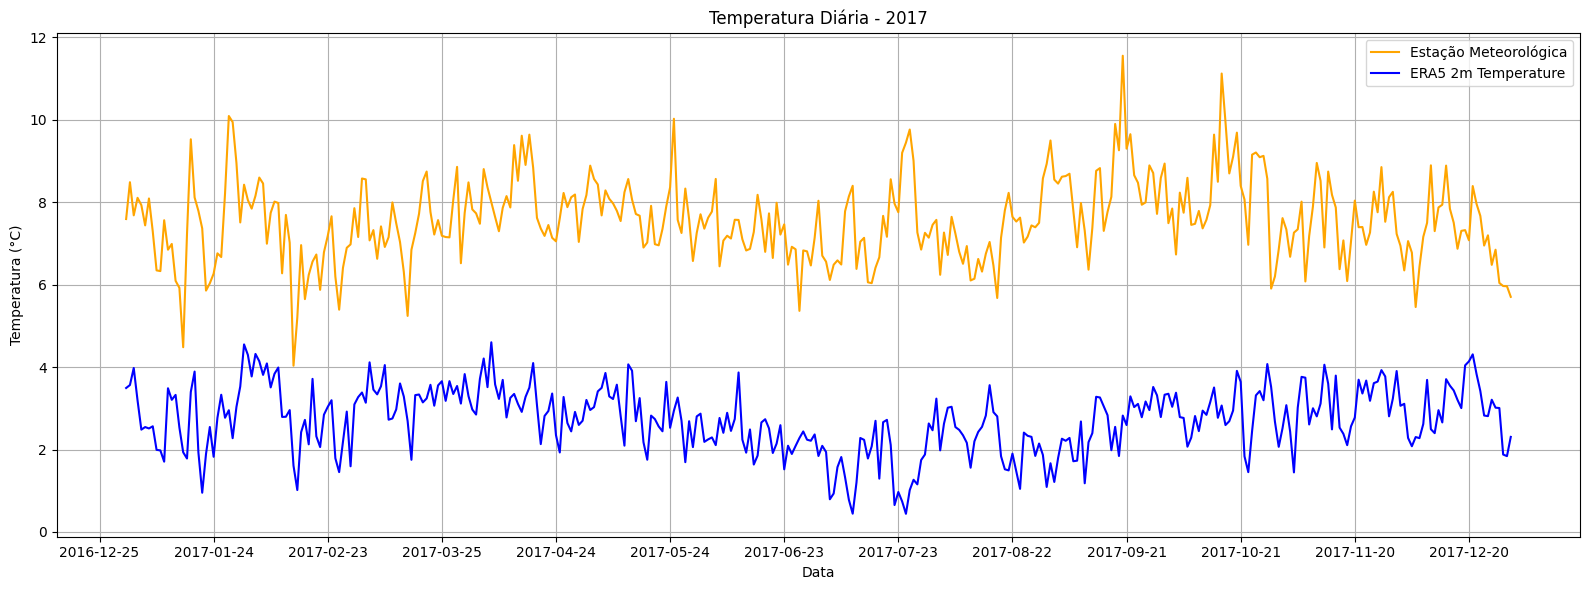

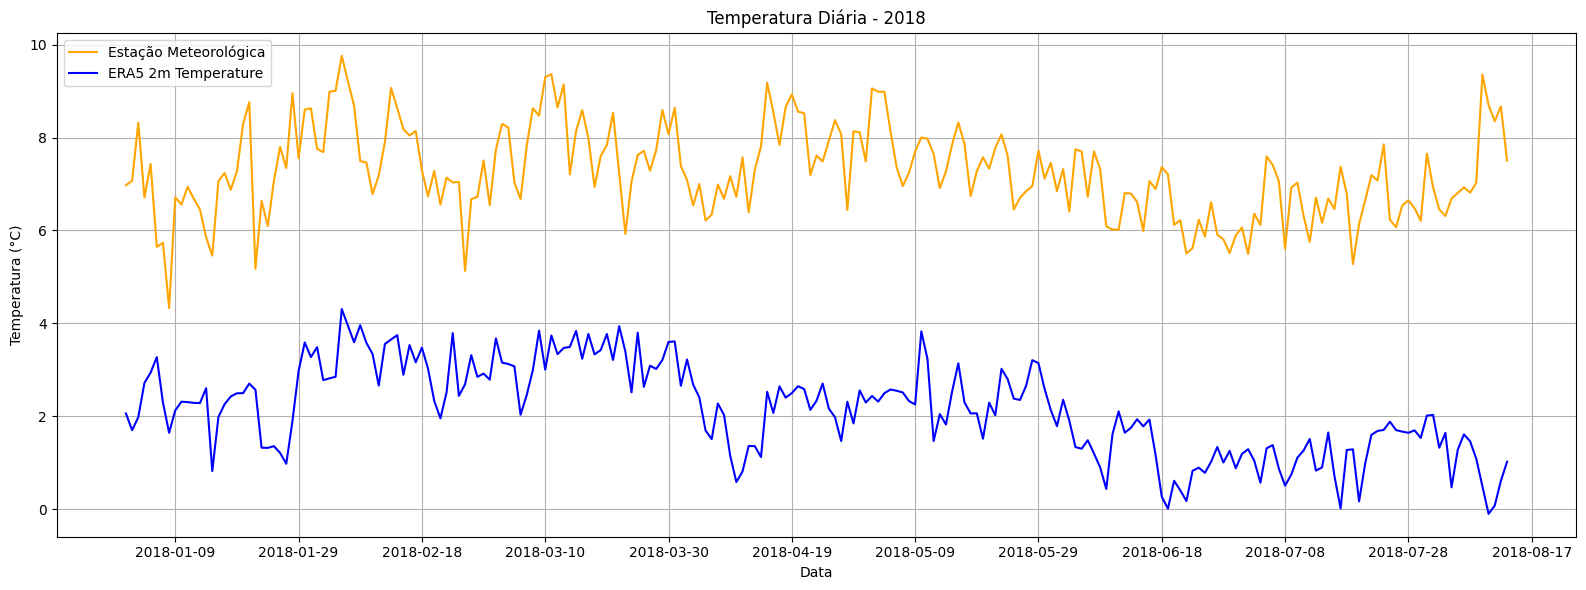

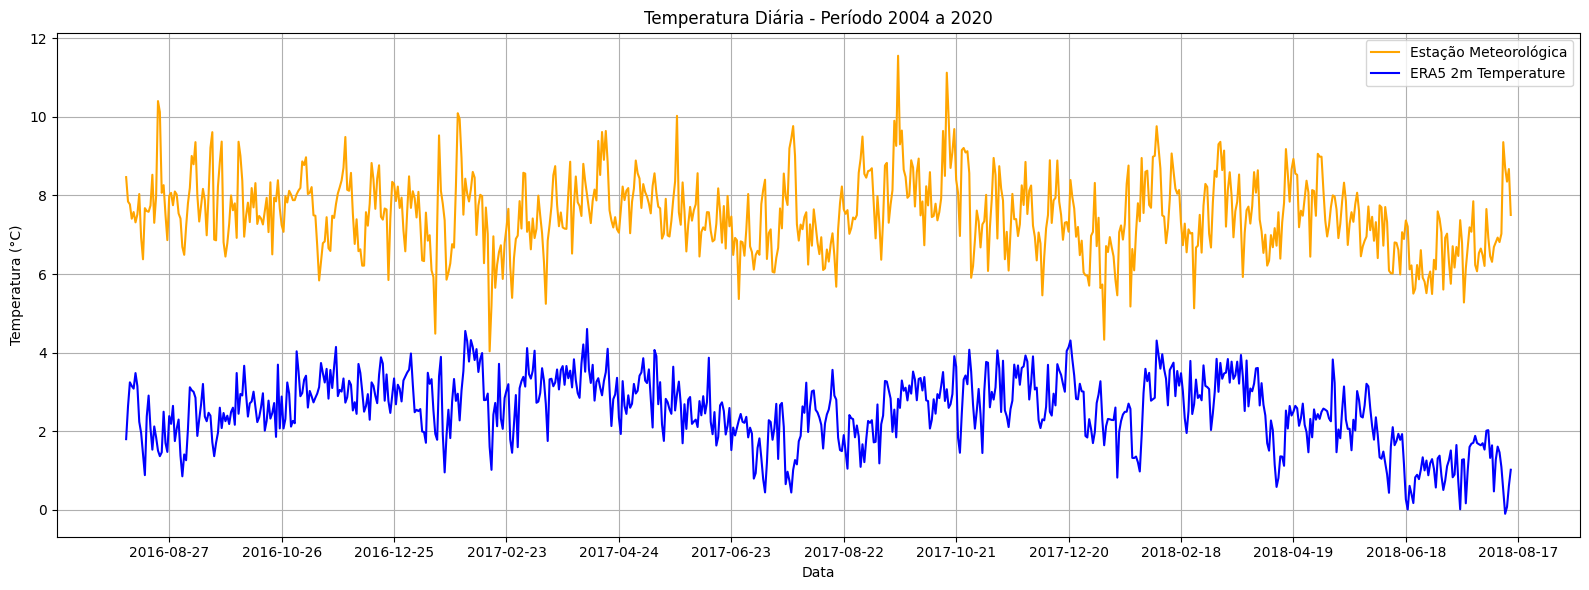

In [13]:
# -----------------------------
# Inicializar a API do Google Earth Engine
# -----------------------------
ee.Initialize()

# -----------------------------
# Dados ERA5‑Land - Temperatura a 2m (Google Earth Engine)
# -----------------------------
# Definir os dados da estação (coordenadas, nome, etc.)
station = {"name": "Llanganuco (LlanQ)", "lat": -9.46, "lon": -77.37, "color": "green"}

# Carregar a coleção de imagens diária do ERA5‑Land e selecionar a variável "temperature_2m"
# OBS.: A temperatura está em Kelvin e será convertida para °C (subtraindo 273.15)
era5_land_daily = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR").select("temperature_2m")

def get_daily_temperature(image_collection, point, start_date, end_date):
    period_collection = image_collection.filterDate(start_date, end_date)
    
    def extract_data(image):
        date = ee.Date(image.get("system:time_start"))
        temp = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=9000,
            maxPixels=1e9
        ).get("temperature_2m")
        return ee.Feature(None, {
            "date": date.format("YYYY-MM-dd"),
            "temperature": ee.Number(temp).subtract(273.15)  # Converter de Kelvin para °C
        })
    
    features = period_collection.map(extract_data).getInfo()["features"]
    data = [
        {
            "date": pd.to_datetime(feature["properties"]["date"]),
            "temperature": feature["properties"]["temperature"]
        }
        for feature in features if feature["properties"]["temperature"] is not None
    ]
    return pd.DataFrame(data)

# Dividir o período (2004 a 2020) em intervalos para evitar limites de requisição
date_ranges = [
    ("2004-01-01", "2006-12-31"),
    ("2007-01-01", "2009-12-31"),
    ("2010-01-01", "2012-12-31"),
    ("2013-01-01", "2015-12-31"),
    ("2016-01-01", "2020-12-31")
]

point = ee.Geometry.Point([station["lon"], station["lat"]])
dfs = []
for start_date, end_date in date_ranges:
    df_temp = get_daily_temperature(era5_land_daily, point, start_date, end_date)
    dfs.append(df_temp)
era5_temp_df = pd.concat(dfs)
era5_temp_df.sort_values(by='date', inplace=True)

# -----------------------------
# Dados da Estação Meteorológica - Temperatura
# -----------------------------
f = '../../Weather Station Data/CasaDeAgua_CDAWX_4July13_1July19.csv'
dados = pd.read_csv(f, encoding="latin1")

df_station = dados

# Converter a coluna de data para datetime e definir como índice
df_station['Datetime'] = pd.to_datetime(df_station['Datetime'], format='%m/%d/%Y %H:%M')
df_station.set_index('Datetime', inplace=True)

# Calcular a média diária da temperatura (°C)
df_station_daily = df_station['Temperature (°C)'].resample('D').mean().reset_index()
# Renomear a coluna 'Datetime' para 'date' para padronização
df_station_daily.rename(columns={'Datetime': 'date', 'Temperature (°C)': 'temperature'}, inplace=True)
df_station_daily.sort_values(by='date', inplace=True)
# Excluir os registros com valores NaN na temperatura
df_station_daily.dropna(subset=['temperature'], inplace=True)

# -----------------------------
# Gráficos Anuais - Comparando Temperatura (Estação vs. ERA5 2m)
# -----------------------------
anos_unicos = df_station_daily['date'].dt.year.unique()

for ano in anos_unicos:
    # Filtrar dados da estação para o ano corrente
    station_ano = df_station_daily[df_station_daily['date'].dt.year == ano]
    # Selecionar apenas os dados ERA5 que possuem data correspondente na estação
    era5_ano = era5_temp_df[era5_temp_df['date'].isin(station_ano['date'])]
    
    if station_ano.empty or era5_ano.empty:
        continue

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(station_ano['date'], station_ano['temperature'], label='Estação Meteorológica', color='orange')
    ax.plot(era5_ano['date'], era5_ano['temperature'], label='ERA5 2m Temperature', color='blue')
    ax.xaxis.set_major_locator(plt.MaxNLocator(14))
    
    ax.set_title(f'Temperatura Diária - {ano}')
    ax.set_xlabel('Data')
    ax.set_ylabel('Temperatura (°C)')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# -----------------------------
# Gráfico do Período Completo (2004 a 2020)
# -----------------------------
# Filtrar ERA5 para datas que também existem na estação meteorológica
era5_matched = era5_temp_df[era5_temp_df['date'].isin(df_station_daily['date'])]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_station_daily['date'], df_station_daily['temperature'], label='Estação Meteorológica', color='orange')
ax.plot(era5_matched['date'], era5_matched['temperature'], label='ERA5 2m Temperature', color='blue')
ax.xaxis.set_major_locator(plt.MaxNLocator(14))

ax.set_title('Temperatura Diária - Período 2004 a 2020')
ax.set_xlabel('Data')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [8]:

# -----------------------------
# Inicializar a API do Google Earth Engine
# -----------------------------
ee.Initialize()

# -----------------------------
# Dados ERA5‑Land - Temperatura a 2m (Google Earth Engine)
# -----------------------------
# Definir os dados da estação (coordenadas, nome, etc.)
station = {"name": "Llanganuco (LlanQ)", "lat": -9.46, "lon": -77.37, "color": "green"}

# Carregar a coleção de imagens diária do ERA5‑Land e selecionar a variável "temperature_2m"
# OBS.: A temperatura está em Kelvin e será convertida para °C (subtraindo 273.15)
era5_land_daily = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR").select("temperature_2m")

def get_daily_temperature(image_collection, point, start_date, end_date):
    period_collection = image_collection.filterDate(start_date, end_date)
    
    def extract_data(image):
        date = ee.Date(image.get("system:time_start"))
        temp = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=9000,
            maxPixels=1e9
        ).get("temperature_2m")
        return ee.Feature(None, {
            "date": date.format("YYYY-MM-dd"),
            "temperature": ee.Number(temp).subtract(273.15)  # Converter de Kelvin para °C
        })
    
    features = period_collection.map(extract_data).getInfo()["features"]
    data = [
        {
            "date": pd.to_datetime(feature["properties"]["date"]),
            "temperature": feature["properties"]["temperature"]
        }
        for feature in features if feature["properties"]["temperature"] is not None
    ]
    return pd.DataFrame(data)

# Dividir o período (2004 a 2020) em intervalos para evitar limites de requisição
date_ranges = [
    ("2004-01-01", "2006-12-31"),
    ("2007-01-01", "2009-12-31"),
    ("2010-01-01", "2012-12-31"),
    ("2013-01-01", "2015-12-31"),
    ("2016-01-01", "2020-12-31")
]

point = ee.Geometry.Point([station["lon"], station["lat"]])
dfs = []
for start_date, end_date in date_ranges:
    df_temp = get_daily_temperature(era5_land_daily, point, start_date, end_date)
    dfs.append(df_temp)
era5_temp_df = pd.concat(dfs)
era5_temp_df.sort_values(by='date', inplace=True)

f = '../../Weather Station Data/CasaDeAgua_CDAWX_4July13_1July19.csv'
dados = pd.read_csv(f, encoding="latin1")

df_station = dados

# Converter a coluna de data para datetime e definir como índice
df_station['Datetime'] = pd.to_datetime(df_station['Datetime'], format='%m/%d/%Y %H:%M')
df_station.set_index('Datetime', inplace=True)

# Calcular a média diária da temperatura (°C)
df_station_daily = df_station['Temperature (°C)'].resample('D').mean().reset_index()
# Renomear a coluna 'Datetime' para 'date' para padronização
df_station_daily.rename(columns={'Datetime': 'date', 'Temperature (°C)': 'temperature'}, inplace=True)
df_station_daily.sort_values(by='date', inplace=True)


 = era5_temp_dfera5_temp_df.set_index('date')
df_station_daily = df_station_daily.set_index('date')
T2_all = pd.merge(era5_temp_df, df_station_daily, how='left', left_index=True, right_index=True)
T2_all.columns = ['ERA5', 'CDAWX']
# 1. Remover linhas que não possuem dados (NaN) em ambas as medições
df_corr = T2_all.dropna(subset=['ERA5', 'CDAWX'])


<Axes: xlabel='date'>

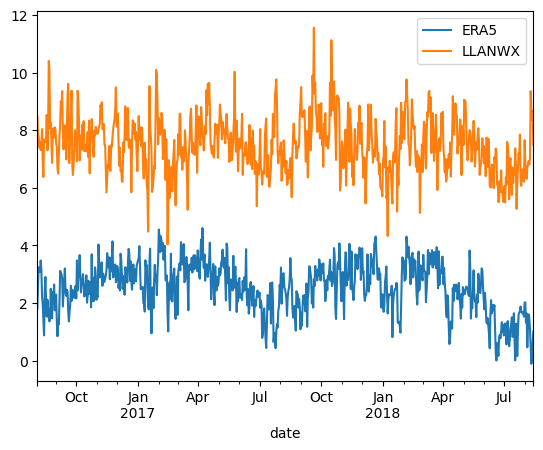

In [6]:
df_corr.plot()

[[1.79735209 2.6308965  3.24401563 ... 0.07303899 0.6080471  1.01883405]
 [8.46645455 7.84552083 7.77372917 ... 8.352375   8.67245833 7.50371053]]
LinearRegression()
[ 0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3
  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7
  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1
  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5
  5.6  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9
  7.   7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3
  8.4  8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7
  9.8  9.9 10.  10.1 10.2 10.3 10.4 10.5 10.6 10.7 10.8 10.9 11.  11.1
 11.2 11.3 11.4 11.5 11.6 11.7 11.8 11.9]


Text(0.05, 0.95, '$r=0.30$\n$Bias=4.98$\n$RMSE=5.10$')

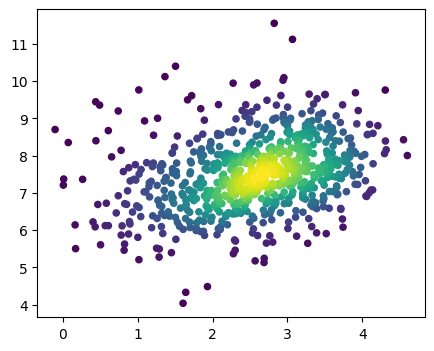

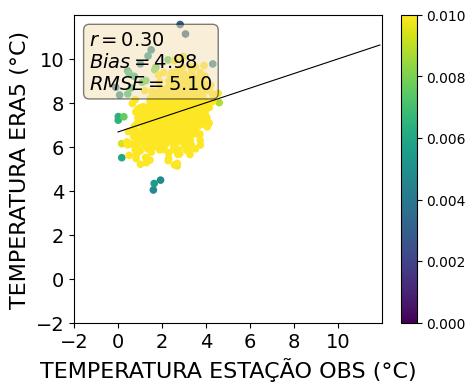

In [12]:
y1 = df_corr['ERA5'].values
y2 = df_corr['CDAWX'].values
idxs = np.arange(len(y1))
#np.random.shuffle(idxs)
n_toplot=10**10
y_expected = y1.reshape(-1)[idxs[:n_toplot]]
y_predicted = y2.reshape(-1)[idxs[:n_toplot]]
xy = np.vstack([y_expected, y_predicted])
print(xy)
z = gaussian_kde(xy)(xy)
idx = z.argsort()
y_plt, ann_plt, z = y_expected[idx], y_predicted[idx], z[idx]

fig = plt.figure(figsize=(5,4))
sc = plt.scatter(y_plt, ann_plt, c=z, s=20)



reg = LinearRegression().fit(y1.reshape(-1, 1),y2)
print(reg)
x_int = np.arange(0,12,0.1)
print(x_int)

def sts_ind_SMB_dec(ds1):
    ds1 = ds1.dropna()
    ds1.columns = ['CDAWX', 'SIM']
    r  = stats.pearsonr(ds1['CDAWX'], ds1['SIM'])[0]
    MBE = np.mean(ds1['SIM'] - ds1['CDAWX']) 
    MSE  = np.square(np.subtract(ds1['CDAWX'], ds1['SIM'])).mean() 
    RMSE = math.sqrt(MSE)

    textstr = '\n'.join((
    r'$r=%.2f$' % (r, ),
    r'$Bias=%.2f$' % (MBE, ),
    r'$RMSE=%.2f$' % (RMSE, )))

    return textstr


fig = plt.figure(figsize=(5,4))
sc = plt.scatter(y_plt, ann_plt, c=z, s=20)

plt.colorbar(sc)
plt.clim(0,0.01)
plt.tick_params(labelsize=14)

plt.ylabel('TEMPERATURA ERA5 (°C)', fontsize=16)
plt.xlabel('TEMPERATURA ESTAÇÃO OBS (°C)', fontsize=16)

plt.gca().set_box_aspect(1)
plt.xticks(np.arange(-2,12,2))
plt.yticks(np.arange(-2,12,2))

plt.xlim(-2, 12)
plt.ylim(-2, 12)

# Adicionamos regressão linea
plt.plot(x_int, reg.intercept_ + reg.coef_ * x_int, linewidth=0.8, color='k', linestyle ='-')

# Vamos adicionar uma caixa para mostrar os indicadores estatísticos. Aqui configuramos as propriedades da caixa
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

# Agora podemos adicionar nossos indicadores estatísticos
plt.text(0.05, 0.95, sts_ind_SMB_dec(df_corr), transform=plt.gca().transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

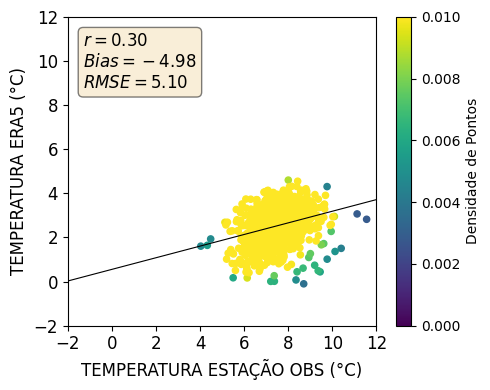

In [14]:
import ee
import pandas as pd
import numpy as np
import math
from scipy import stats
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -----------------------------
# Inicializar a API do Google Earth Engine
# -----------------------------
ee.Initialize()

# -----------------------------
# Dados ERA5‑Land - Temperatura a 2m (Google Earth Engine)
# -----------------------------
# Definir os dados da estação (coordenadas, nome, etc.)
station = {"name": "Llanganuco (LlanQ)", "lat": -9.46, "lon": -77.37, "color": "green"}

# Carregar a coleção de imagens diária do ERA5‑Land e selecionar a variável "temperature_2m"
# OBS.: A temperatura está em Kelvin e será convertida para °C (subtraindo 273.15)
era5_land_daily = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR").select("temperature_2m")

def get_daily_temperature(image_collection, point, start_date, end_date):
    period_collection = image_collection.filterDate(start_date, end_date)
    
    def extract_data(image):
        date = ee.Date(image.get("system:time_start"))
        temp = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=9000,
            maxPixels=1e9
        ).get("temperature_2m")
        return ee.Feature(None, {
            "date": date.format("YYYY-MM-dd"),
            "temperature": ee.Number(temp).subtract(273.15)  # Converter de Kelvin para °C
        })
    
    features = period_collection.map(extract_data).getInfo()["features"]
    data = [
        {
            "date": pd.to_datetime(feature["properties"]["date"]),
            "temperature": feature["properties"]["temperature"]
        }
        for feature in features if feature["properties"]["temperature"] is not None
    ]
    return pd.DataFrame(data)

# Dividir o período (2004 a 2020) em intervalos para evitar limites de requisição
date_ranges = [
    ("2004-01-01", "2006-12-31"),
    ("2007-01-01", "2009-12-31"),
    ("2010-01-01", "2012-12-31"),
    ("2013-01-01", "2015-12-31"),
    ("2016-01-01", "2020-12-31")
]

point = ee.Geometry.Point([station["lon"], station["lat"]])
dfs = []
for start_date, end_date in date_ranges:
    df_temp = get_daily_temperature(era5_land_daily, point, start_date, end_date)
    dfs.append(df_temp)
era5_temp_df = pd.concat(dfs)
era5_temp_df.sort_values(by='date', inplace=True)

# -----------------------------
# Ler dados da estação local
# -----------------------------
f = '../../Weather Station Data/CasaDeAgua_CDAWX_4July13_1July19.csv'
dados = pd.read_csv(f, encoding="latin1")

df_station = dados.copy()

# Converter a coluna de data para datetime e definir como índice
df_station['Datetime'] = pd.to_datetime(df_station['Datetime'], format='%m/%d/%Y %H:%M')
df_station.set_index('Datetime', inplace=True)

# Calcular a média diária da temperatura (°C)
df_station_daily = df_station['Temperature (°C)'].resample('D').mean().reset_index()
# Renomear a coluna 'Datetime' para 'date' para padronização
df_station_daily.rename(columns={'Datetime': 'date', 'Temperature (°C)': 'temperature'}, inplace=True)
df_station_daily.sort_values(by='date', inplace=True)

# -----------------------------
# Unir dados ERA5 e dados de estação
# -----------------------------
era5_temp_df = era5_temp_df.set_index('date')
df_station_daily = df_station_daily.set_index('date')

T2_all = pd.merge(era5_temp_df, df_station_daily, how='left', left_index=True, right_index=True)
# Renomear para que fique claro: primeira coluna = Estação, segunda coluna = ERA5
# Aqui assumimos que era5_temp_df veio primeiro, então a 1ª coluna é do ERA5 e a 2ª é da estação.
# Vamos inverter para X=Estação, Y=ERA5:
T2_all.columns = ['ERA5', 'Station']
# Reordenar colunas para [Station, ERA5]
T2_all = T2_all[['Station', 'ERA5']]

# Remover linhas que não possuem dados (NaN)
df_corr = T2_all.dropna(subset=['Station', 'ERA5'])

# -----------------------------
# Função de estatísticas
# -----------------------------
def sts_ind_SMB_dec(ds):
    # Garantir que a ordem seja [OBS, SIM] = [Station, ERA5]
    ds = ds.dropna().copy()
    ds.columns = ['OBS', 'SIM']  # OBS = Estação, SIM = ERA5
    
    r  = stats.pearsonr(ds['OBS'], ds['SIM'])[0]
    MBE = np.mean(ds['SIM'] - ds['OBS'])   # ERA5 - Estação
    MSE = np.mean((ds['SIM'] - ds['OBS'])**2)
    RMSE = math.sqrt(MSE)

    textstr = '\n'.join((
        r'$r=%.2f$' % (r, ),
        r'$Bias=%.2f$' % (MBE, ),
        r'$RMSE=%.2f$' % (RMSE, )
    ))
    return textstr

# -----------------------------
# Preparar vetores para scatter
# -----------------------------
# Agora X = Station, Y = ERA5
x_vals = df_corr['Station'].values
y_vals = df_corr['ERA5'].values

# Para o cálculo de densidade e ordenamento dos pontos
xy = np.vstack([x_vals, y_vals])
z = gaussian_kde(xy)(xy)
idx = z.argsort()  # índice que ordena do menor para o maior valor de densidade
x_plt, y_plt, z_plt = x_vals[idx], y_vals[idx], z[idx]

# -----------------------------
# Ajustar regressão linear (X=Estação, Y=ERA5)
# -----------------------------
reg = LinearRegression().fit(x_vals.reshape(-1, 1), y_vals)
x_min, x_max = -2, 12  # limites de interesse
x_int = np.linspace(x_min, x_max, 100)
y_reg = reg.intercept_ + reg.coef_[0] * x_int

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(5,4))
sc = plt.scatter(x_plt, y_plt, c=z_plt, s=20)
plt.plot(x_int, y_reg, 'k-', linewidth=0.8)  # linha de regressão

# Ajustes de cor e rótulos
plt.colorbar(sc, label='Densidade de Pontos')
plt.clim(0, 0.01)

plt.xlabel('TEMPERATURA ESTAÇÃO OBS (°C)', fontsize=12)
plt.ylabel('TEMPERATURA ERA5 (°C)', fontsize=12)

plt.xlim(x_min, x_max)
plt.ylim(x_min, x_max)
plt.xticks(np.arange(x_min, x_max+1, 2))
plt.yticks(np.arange(x_min, x_max+1, 2))
plt.tick_params(labelsize=12)
plt.gca().set_box_aspect(1)  # deixar o gráfico quadrado

# Adicionar caixa com indicadores estatísticos
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
stats_text = sts_ind_SMB_dec(df_corr)
plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()
